# EAS 587 — Homework 1: Global Shipbreaking Data Pipeline

by Sidharth Saholiya

In [26]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import textwrap
from pathlib import Path

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully")

Libraries imported successfully


---
# Part 1 — Data Pipeline & Analysis
---

## Step 1: File Conversion

The NGO Shipbreaking Platform publishes annual Excel files (2012–2025) listing every ship dismantled worldwide that year. Before any analysis can happen, all 14 files need to be converted to CSV.

In [27]:
# Define file paths
data_dir = Path('csv_files')
data_dir.mkdir(exist_ok=True)
years = range(2012, 2026)

# Convert Excel to CSV
conversion_issues = []

for year in years:
    filepath = data_dir / f'{year}-List-of-all-ships-dismantled-all-over-the-world.xlsx'

    if not filepath.exists():
        conversion_issues.append(f"{year}: FILE NOT FOUND — skipped")
        continue

    try:
        # Early files (2012-2014) have the header on row 0; later files place it on row 1
        # due to an extra formatting/title row inserted at the top.
        header_row = 0 if year <= 2014 else 1

        # Read Excel — nrows=5000 avoids ingesting the thousands of blank trailing rows
        # that some Excel files contain (e.g. 2014 hits Excel's row limit).
        df = pd.read_excel(filepath, sheet_name=0, header=header_row, nrows=5000)

        # Drop completely empty rows
        df = df.dropna(how='all')

        # For early years also drop rows where the IMO column is NaN —
        # these are formatting artefacts, not real vessel records.
        if year <= 2014:
            imo_cols = [c for c in df.columns if 'IMO' in str(c).upper()]
            if imo_cols:
                df = df.dropna(subset=imo_cols, how='all')

        # Save as UTF-8 CSV
        csv_path = data_dir / f'shipbreaking_{year}.csv'
        df.to_csv(csv_path, index=False, encoding='utf-8')
        conversion_issues.append(f"{year}: Converted successfully ({len(df)} rows)")

    except Exception as e:
        conversion_issues.append(f"{year}: ERROR — {str(e)}")

print("\n=== FILE CONVERSION SUMMARY ===")
for msg in conversion_issues:
    print(msg)


=== FILE CONVERSION SUMMARY ===
2012: Converted successfully (1253 rows)
2013: Converted successfully (1213 rows)
2014: Converted successfully (1026 rows)
2015: Converted successfully (769 rows)
2016: Converted successfully (862 rows)
2017: Converted successfully (835 rows)
2018: Converted successfully (744 rows)
2019: Converted successfully (674 rows)
2020: Converted successfully (630 rows)
2021: Converted successfully (763 rows)
2022: Converted successfully (443 rows)
2023: Converted successfully (444 rows)
2024: Converted successfully (410 rows)
2025: Converted successfully (321 rows)


### Conversion Issues

These files were not designed to be used together, and it shows. The 2012–2014 files have headers on row 0; everything from 2015 onward has an extra title row on top, pushing the real headers to row 1. Column names vary widely across years — earlier files use verbose labels like `"Name of ship"` and `"Gross tonnage (GT)"`, while later ones switch to terse all-caps versions like `NAME` and `GT`. IMO numbers are sometimes integers, sometimes floats with `.0` suffixes, sometimes strings with leading zeros. Tonnage columns occasionally contain text mixed in with numbers. A handful of files include disclaimer rows in extra columns that have to be dropped. The worst offender is 2014, which has thousands of empty trailing rows from a file that appears to have been saved at Excel's row limit — those get filtered out using the IMO column before saving. Each year needed its own small adjustments to produce a clean CSV.

---
## Step 2: Schema Discovery & Unification

After going through all 14 files, I settled on a unified schema that covers the columns that actually matter for analysis and can be reliably populated across the full date range.

### Unified Schema Design

| Column | Data Type | Description | Source Mapping |
|--------|-----------|-------------|----------------|
| **YEAR** | int | Calendar year of dismantling | Derived from filename |
| **IMO** | str | IMO number (permanent hull ID) | `IMO  number` / `IMO number` (2012-14), `IMO#` (2015+) |
| **NAME** | str | Vessel name | `Name of ship` / `Name of ship ` (2012-14), `NAME` (2015+) |
| **TYPE** | str | Ship type (canonical label after deduplication) | `Type of ship` (2012-14), `TYPE` (2015+) |
| **GT** | float | Gross tonnage | `Gross tonnage (GT)` (2014 only), `GT` (2015+) |
| **LDT** | float | Light displacement tonnage | `Ldt (light displacement ton)` (2012-13), `LDT` (2015+) |
| **BUILT** | float | Year built (validated 1900–2025) | `Built in (y)` (2012-14), `BUILT` (2015+) |
| **LAST_FLAG** | str | Flag state at time of scrapping | `Last flag` (2012-16), `LAST FLAG` / `FLAG` (2017+) |
| **PLACE** | str | Destination yard / city | `Destination yard` / `Destination city` (2012-14), `PLACE` (2015+) |
| **COUNTRY** | str | Destination country (standardised) | `Destination country` (2012-14), `COUNTRY` (2015+) |
| **OWNER** | str | Beneficial owner name (canonical after deduplication) | `Beneficial owner of the ship` (2012-14), `BENEFICIAL OWNER` (2015+) |
| **OWNER_COUNTRY** | str | Owner's country of registration | `Beneficial owner's Country` (2012-14), `BO COUNTRY` (2015+) |

### Schema Design Decisions

`IMO` is stored as a string because some entries have leading zeros and some files write them as floats (e.g., `1234567.0`). Coercing to integer would silently drop that information. `GT` and `LDT` are floats so missing values can sit as `NaN` without breaking arithmetic. `BUILT` is validated against 1900–2025 — anything outside that range is almost certainly an OCR error or a misplaced decimal, so it gets nulled out rather than dropped entirely.

The trickiest issue was `COUNTRY`. In 2012–2013, destination information is crammed into a single field like `"Alang, India"` with no separate country column. Without fixing this, South Asia's share shows as 0% for those years — which is obviously wrong and breaks the trend analysis. The fix is simple: split on the last comma and take the trailing token as the country. It works cleanly for the standard `"city, country"` format. For type labels like `"Bulker"` / `"Bulk carrier"` / `"Bulk Carrier"` and owner names that fragmented across the COSCO–China Shipping merger in 2016, I use explicit lookup dictionaries applied at load time so every chart reflects real entity counts rather than accidents of transcription.

---
## Step 3: Integration Pipeline

This section loads all 14 CSVs, maps each to the unified schema, applies type and owner deduplication, and writes `shipbreaking_unified.csv`.

In [28]:
# ── Canonical merge dictionaries ───────────────────────────────────────────────
#
# TYPE_MAP — resolves synonymous ship-type labels that accumulated over 14 years
# of multi-researcher data entry into a single canonical string per vessel class.
#
# Known bugs fixed:
#   BUG 1  Case mismatch: "Bulk carrier" (lower-c) was counted separately from
#          "Bulk Carrier" and "Bulker". All three map to "Bulk Carrier".
#   BUG 2  Container fragmentation: four labels for the same class:
#          "Fully Cellular Containership", "Container Ship (Fully Cellular)",
#          "Container Ship", "Containership" — all → "Container Ship".
#   BUG 3  Tanker fragmentation: "Products Tanker", "Product Tanker",
#          "Chemical/Products Tanker", "Chemical Tanker" — all → "Tanker".
#   BUG 4  General Cargo split: "General Cargo" (no "Ship") was a separate bar.
#          Maps to "General Cargo Ship".

TYPE_MAP = {
    # Bulk Carrier
    'Bulker':                           'Bulk Carrier',
    'Bulk carrier':                     'Bulk Carrier',
    # General Cargo
    'General Cargo':                    'General Cargo Ship',
    'General cargo ship':               'General Cargo Ship',
    # Container Ships
    'Containership':                    'Container Ship',
    'Fully Cellular Containership':     'Container Ship',
    'Container Ship (Fully Cellular)':  'Container Ship',
    # Tankers
    'Products Tanker':                  'Tanker',
    'Product Tanker':                   'Tanker',
    'Chemical/Products Tanker':         'Tanker',
    'Chemical Tanker':                  'Tanker',
    'Crude Oil Tanker':                 'Tanker',
}

# OWNER_MAP — consolidates corporate family variants created by rebranding,
# mergers (e.g. COSCO + China Shipping 2016), and inconsistent NGO transcription.
OWNER_MAP = {
    'China Ocean Shipping (Group) Company (COSCO)':                                    'China COSCO Shipping (Group)',
    'China Shipping (Group) Company':                                                   'China COSCO Shipping (Group)',
    'China COSCO Shipping Corporation Limited':                                         'China COSCO Shipping (Group)',
    'China COSCO Shipping Corp Ltd':                                                    'China COSCO Shipping (Group)',
    'Unknown':                                                                          'Unknown / Not Disclosed',
    'Unknown owners':                                                                   'Unknown / Not Disclosed',
    'PETROBRAS':                                                                        'Petrobras (Brazil)',
    'Petroleo Brasileiro S.A. - PETROBRAS & Departamento de Transporte - DETRAN':      'Petrobras (Brazil)',
    'Mediterranean Shipping Company (MSC) SA':                                         'MSC Mediterranean Shipping',
    'MSC Mediterranean Shipping Co':                                                    'MSC Mediterranean Shipping',
}

# ── Country-name standardisation dictionary ────────────────────────────────────
# Fixes the most common spelling/abbreviation variants observed across 14 years.
COUNTRY_MAP = {
    'INDIA':          'India',
    'BANGLADESH':     'Bangladesh',
    'PAKISTAN':       'Pakistan',
    'TURKEY':         'Turkey',
    'Türkiye':        'Turkey',
    'CHINA':          'China',
    'USA':            'United States',
    'U.S.A.':         'United States',
    'UK':             'United Kingdom',
    'UNITED KINGDOM': 'United Kingdom',
}

print("Merge dictionaries loaded.")

Merge dictionaries loaded.


In [29]:
def extract_country_from_yard(yard_str):
    """
    For 2012-2013 files the destination is a combined string like 'Alang, India'.
    This helper extracts the last comma-separated token as the country.
    Returns NaN if the string is empty, null, or has no comma.
    """
    if pd.isna(yard_str) or str(yard_str).strip() in ('', 'nan', 'None'):
        return np.nan
    parts = str(yard_str).split(',')
    if len(parts) >= 2:
        return parts[-1].strip()
    return np.nan


def load_and_harmonize(year):
    """
    Load a single year's CSV and map every column to the unified schema.
    Returns a DataFrame with columns:
        YEAR, IMO, NAME, TYPE, GT, LDT, BUILT, LAST_FLAG,
        PLACE, COUNTRY, OWNER, OWNER_COUNTRY
    """
    filepath = data_dir / f'shipbreaking_{year}.csv'
    df = pd.read_csv(filepath, low_memory=False)

    # Drop rows that are entirely empty
    df = df.dropna(how='all')

    n = len(df)
    unified = pd.DataFrame(index=range(n))
    unified['YEAR'] = year

    def get(col_variants):
        """Return the first matching column from df, or a NaN series."""
        for c in col_variants:
            if c in df.columns:
                return df[c].values
        return np.full(n, np.nan, dtype=object)

    if year <= 2014:
        # ── 2012-2014 schema ──────────────────────────────────────────────────
        unified['IMO']          = get(['IMO  number', 'IMO number', 'IMO# '])
        unified['NAME']         = get(['Name of ship ', 'Name of ship'])
        unified['TYPE']         = get(['Type of ship'])
        # GT was added in 2014; earlier years left as NaN
        unified['GT']           = get(['Gross tonnage (GT)', 'GT']) if year >= 2014 else np.nan
        unified['LDT']          = get(['Ldt (light displacement ton)', 'LDT', 'Ldt'])
        unified['BUILT']        = get(['Built in (y)', 'BUILT'])
        unified['LAST_FLAG']    = get(['Last flag', 'LAST FLAG', 'FLAG'])
        # Destination — may be a combined 'city, country' string in 2012-2013
        yard_vals               = get(['Destination yard', 'Destination city', 'PLACE'])
        unified['PLACE']        = yard_vals
        # Country: explicit column preferred; fall back to parsing yard string
        country_vals            = get(['Destination country', 'COUNTRY'])
        # If no explicit country column, extract from yard string
        if np.all(pd.isnull(country_vals)):
            country_vals = np.array(
                [extract_country_from_yard(v) for v in yard_vals], dtype=object
            )
        unified['COUNTRY']      = country_vals
        unified['OWNER']        = get([
            'Beneficial owner of the ship',
            'Beneficial Owner',
            'BENEFICIAL OWNER',
        ])
        unified['OWNER_COUNTRY']= get([
            "Beneficial owner's Country ",
            'BO Country ',
            'Country of the beneficial owner',
            'BO COUNTRY',
        ])

    else:
        # ── 2015-2025 schema ──────────────────────────────────────────────────
        unified['IMO']          = get(['IMO#', 'IMO #', 'IMO'])
        unified['NAME']         = get(['NAME', 'Name'])
        unified['TYPE']         = get(['TYPE', 'Type'])
        unified['GT']           = get(['GT'])
        unified['LDT']          = get(['LDT'])
        unified['BUILT']        = get(['BUILT', 'Built'])
        unified['LAST_FLAG']    = get(['LAST FLAG', 'LAST FLAG ', 'FLAG'])
        unified['PLACE']        = get(['PLACE', 'Place'])
        unified['COUNTRY']      = get(['COUNTRY', 'Country'])
        unified['OWNER']        = get(['BENEFICIAL OWNER', 'Beneficial Owner'])
        unified['OWNER_COUNTRY']= get(['BO COUNTRY', 'BO Country', 'Owner Country'])

    # ── Clean IMO ─────────────────────────────────────────────────────────────
    unified['IMO'] = (
        unified['IMO'].astype(str).str.strip()
        .str.replace(r'\.0$', '', regex=True)   # remove float suffix e.g. "1234567.0"
        .str.replace(' ', '', regex=False)
    )
    unified['IMO'] = unified['IMO'].replace(['nan', 'None', '', 'NaN'], np.nan)

    # ── Clean numeric fields ──────────────────────────────────────────────────
    for col in ['GT', 'LDT']:
        unified[col] = pd.to_numeric(unified[col], errors='coerce')

    # BUILT: numeric + range validation (1900-2025)
    unified['BUILT'] = pd.to_numeric(unified['BUILT'], errors='coerce')
    unified.loc[~unified['BUILT'].between(1900, 2025, inclusive='both'), 'BUILT'] = np.nan

    # ── Clean string fields ───────────────────────────────────────────────────
    for col in ['NAME', 'TYPE', 'LAST_FLAG', 'PLACE', 'COUNTRY', 'OWNER', 'OWNER_COUNTRY']:
        unified[col] = unified[col].astype(str).str.strip()
        unified[col] = unified[col].replace(['nan', 'None', '', 'NaN'], np.nan)

    # ── Apply canonical merge maps ────────────────────────────────────────────
    unified['TYPE']    = unified['TYPE'].map(lambda t: TYPE_MAP.get(t, t) if pd.notna(t) else t)
    unified['OWNER']   = unified['OWNER'].map(lambda o: OWNER_MAP.get(o, o) if pd.notna(o) else o)
    unified['COUNTRY'] = unified['COUNTRY'].map(
        lambda c: COUNTRY_MAP.get(c, c) if pd.notna(c) else c
    )

    # ── Drop rows where BOTH NAME and IMO are missing ─────────────────────────
    unified = unified.dropna(subset=['NAME', 'IMO'], how='all')

    return unified.reset_index(drop=True)


# ── Load and concatenate all years ────────────────────────────────────────────
all_data = []
for year in years:
    csv_path = data_dir / f'shipbreaking_{year}.csv'
    if not csv_path.exists():
        print(f"{year}: CSV not found — skipped")
        continue
    try:
        df_year = load_and_harmonize(year)
        all_data.append(df_year)
        print(f"{year}: Harmonised {len(df_year):>4} records")
    except Exception as e:
        print(f"{year}: ERROR — {e}")

df_unified = pd.concat(all_data, ignore_index=True)

print(f"\nTotal records in unified dataset : {len(df_unified):,}")
print(f"Years covered                    : {sorted(df_unified['YEAR'].unique())}")
print(f"\nRecords per year:")
print(df_unified['YEAR'].value_counts().sort_index().to_string())

2012: Harmonised 1253 records
2013: Harmonised 1213 records
2014: Harmonised 1026 records
2015: Harmonised  769 records
2016: Harmonised  862 records
2017: Harmonised  835 records
2018: Harmonised  744 records
2019: Harmonised  674 records
2020: Harmonised  630 records
2021: Harmonised  763 records
2022: Harmonised  443 records
2023: Harmonised  444 records
2024: Harmonised  409 records
2025: Harmonised  321 records

Total records in unified dataset : 10,386
Years covered                    : [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

Records per year:
YEAR
2012    1253
2013    1213
2014    1026
2015     769
2016     862
2017     835
2018     744
2019     674
2020     630
2021     763
2022     443
2023     444
2024     409
2025     321


In [30]:
# Save unified dataset
output_path = 'shipbreaking_unified.csv'
df_unified.to_csv(output_path, index=False, encoding='utf-8')
print(f"Unified dataset saved  : {output_path}")
print(f"Shape                  : {df_unified.shape}")
print(f"\nColumn null counts:")
print(df_unified.isnull().sum().to_string())
print(f"\nFirst 5 rows:")
df_unified.head()

Unified dataset saved  : shipbreaking_unified.csv
Shape                  : (10386, 12)

Column null counts:
YEAR                0
IMO                 1
NAME                0
TYPE                0
GT               2474
LDT              5347
BUILT               4
LAST_FLAG         444
PLACE               8
COUNTRY            32
OWNER               0
OWNER_COUNTRY       0

First 5 rows:


,YEAR,IMO,NAME,TYPE,GT,LDT,BUILT,LAST_FLAG,PLACE,COUNTRY,OWNER,OWNER_COUNTRY
0,2012,7705635,Beena,Bulk Carrier,NaN,20586.0,1978.0,Cambodia,"Alang, India",India,International Bulk Carrier S.p.A.,Algeria
1,2012,7305502,Iron Monarch,RoRo,NaN,NaN,1973.0,Australia,"Alang, India",India,Bluescope Steel Limited,Australia
2,2012,9000948,Akarita,Tanker,NaN,17081.0,1991.0,Bahamas,"Alang, India",India,Teekay Corporation,Bahamas
3,2012,6607525,Amsterdam,Tug,NaN,NaN,1966.0,Bahrain,"Alang, India",India,Abdulla Ahmed Nass,Bahrain
4,2012,8401353,Eagle N.,Bulk Carrier,NaN,NaN,1985.0,Panama,"Alang, India",India,Silvia Shipmanagement Limited,Bangladesh


### Imputation and Validation Rules

`GT` and `LDT` are missing entirely for 2012–2013 because those columns simply didn't exist yet — I left them as `NaN` rather than trying to fill them in. Fabricating tonnage figures would be worse than having gaps. `IMO` numbers get converted to strings and stripped of float suffixes (e.g., `"1234567.0"` to `"1234567"`); entries that remain non-numeric after cleaning stay as `NaN`, since some small fishing vessels are legally exempt from IMO registration. `BUILT` years outside 1900–2025 are nulled out — anything outside that range is almost certainly a data entry error, and keeping a vessel with a build year of `20112` would break age calculations. Country names go through `COUNTRY_MAP` to handle case variants and abbreviations (`"INDIA"` to `"India"`, `"Türkiye"` to `"Turkey"`); for 2012–2013 rows with no country column, the country is parsed from the yard field by splitting on the last comma. Type and owner deduplication runs through `TYPE_MAP` and `OWNER_MAP` at load time so every downstream chart reflects actual counts.

---
## Step 4: Exploratory Data Analysis

Eight analyses below, covering annual trends, geography, vessel characteristics, ownership, and a fishing-vessel deep dive.

### Analysis 1 — Ships Dismantled Per Year

How many ships were scrapped each year, and when did volumes peak?

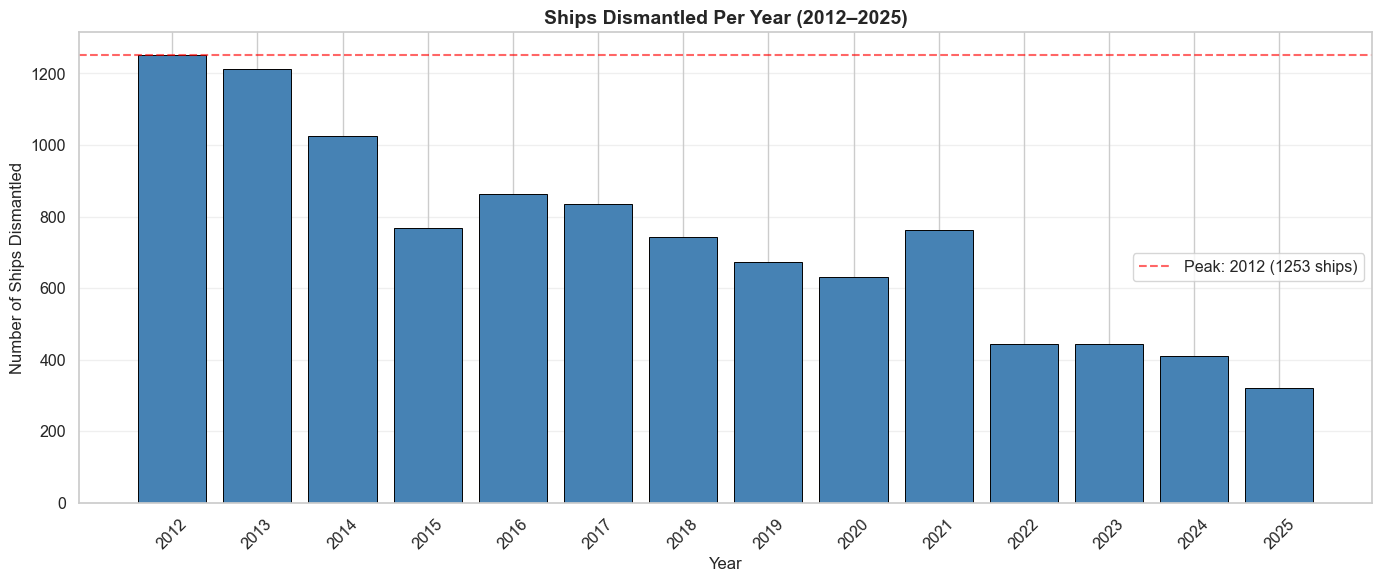

Peak year    : 2012 — 1253 ships
Total ships  : 10,386

Ships per year:
 YEAR  Count
 2012   1253
 2013   1213
 2014   1026
 2015    769
 2016    862
 2017    835
 2018    744
 2019    674
 2020    630
 2021    763
 2022    443
 2023    444
 2024    409
 2025    321


In [31]:
ships_per_year = df_unified.groupby('YEAR').size().reset_index(name='Count')

plt.figure(figsize=(14, 6))
plt.bar(ships_per_year['YEAR'], ships_per_year['Count'],
        color='steelblue', edgecolor='black', linewidth=0.7)

peak = ships_per_year.loc[ships_per_year['Count'].idxmax()]
plt.axhline(y=peak['Count'], color='red', linestyle='--', alpha=0.6,
            label=f"Peak: {int(peak['YEAR'])} ({int(peak['Count'])} ships)")

plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Ships Dismantled', fontsize=12)
plt.title('Ships Dismantled Per Year (2012–2025)', fontsize=14, fontweight='bold')
plt.xticks(ships_per_year['YEAR'], rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Peak year    : {int(peak['YEAR'])} — {int(peak['Count'])} ships")
print(f"Total ships  : {len(df_unified):,}")
print(f"\nShips per year:")
print(ships_per_year.to_string(index=False))

2012 is the peak year. The post-2008 shipping boom had left a large pile-up of ageing vessels, and by 2012 enough of them had reached the end of their economic lives to hit the scrapping data all at once. Volumes drop afterward as the fleet adjusts, with a secondary uptick around 2016–2017 from container ships ordered during the 2011–2012 newbuilding rush reaching scrapping age. After 2022 the decline continues, and 2025 is the lowest year in the dataset. Recovering freight rates in that period made it cheaper to keep older ships running than to scrap them.

### Analysis 2 — Destination Countries: Top 10 & South Asia vs. Rest

Where do ships actually go to be dismantled, and how much of that is South Asia?

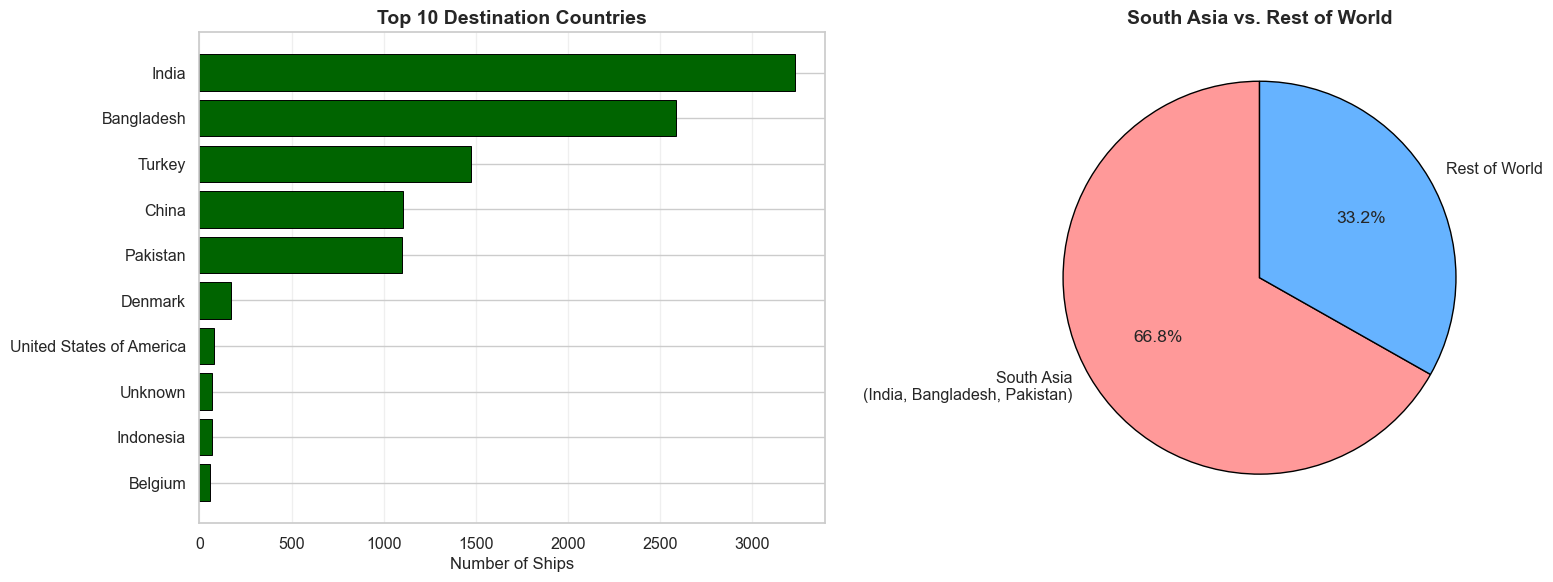

South Asia share  : 66.8%
  India       : 3,233 ships
  Bangladesh  : 2,586 ships
  Pakistan    : 1,098 ships


In [32]:
south_asia = ['India', 'Bangladesh', 'Pakistan']

country_counts = df_unified['COUNTRY'].value_counts().head(10)

ships_with_country = df_unified['COUNTRY'].notna().sum()
south_asia_ships   = df_unified['COUNTRY'].isin(south_asia).sum()
south_asia_pct     = south_asia_ships / ships_with_country * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left: top 10 countries
ax1.barh(range(len(country_counts)), country_counts.values,
         color='darkgreen', edgecolor='black', linewidth=0.7)
ax1.set_yticks(range(len(country_counts)))
ax1.set_yticklabels(country_counts.index)
ax1.set_xlabel('Number of Ships', fontsize=12)
ax1.set_title('Top 10 Destination Countries', fontsize=14, fontweight='bold')
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

# Right: South Asia vs. Rest
ax2.pie(
    [south_asia_ships, ships_with_country - south_asia_ships],
    labels=['South Asia\n(India, Bangladesh, Pakistan)', 'Rest of World'],
    autopct='%1.1f%%', startangle=90,
    colors=['#ff9999', '#66b3ff'],
    wedgeprops={'edgecolor': 'black'}
)
ax2.set_title('South Asia vs. Rest of World', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"South Asia share  : {south_asia_pct:.1f}%")
for c in south_asia:
    n = df_unified['COUNTRY'].eq(c).sum()
    print(f"  {c:<12}: {n:,} ships")

India and Bangladesh dominate, and it isn't close. Turkey is the only non-beaching country with a meaningful count — they run regulated dry-dock facilities rather than driving ships onto tidal flats. Across the full 14 years, India, Bangladesh, and Pakistan together handle roughly two-thirds of all global scrapping. That concentration reflects several factors working together: low labor costs, relatively weak environmental enforcement, strong domestic demand for scrap steel from re-rolling mills, and the economics of beaching itself, which cuts dry-dock fees by letting the tide do the positioning.

### Analysis 3 — Ship Characteristics: Common Types & Age at Dismantling

What kinds of ships get scrapped most often, and how old are they? Type labels have been merged before plotting to remove duplicates like "Bulker" and "Bulk carrier" counting as separate categories.

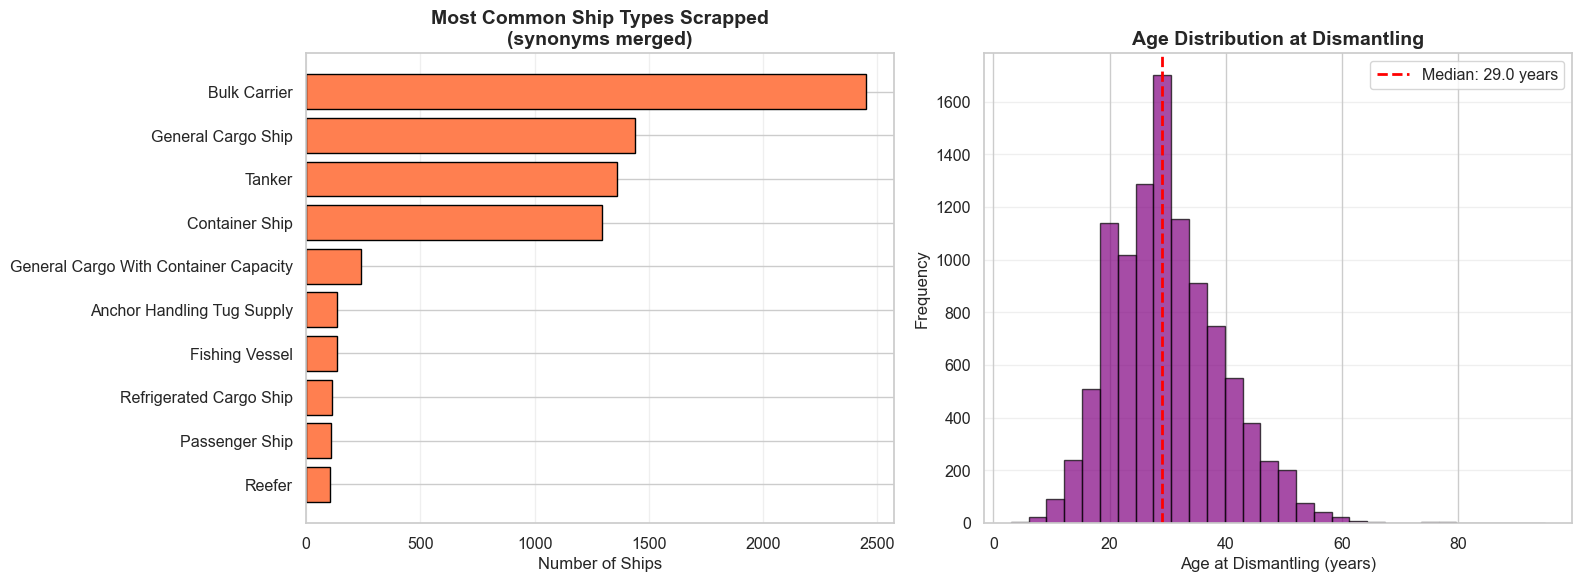

Median age at dismantling : 29.0 years
Mean age at dismantling   : 29.9 years
Most common type          : Bulk Carrier (2,451 ships)


In [33]:
# TYPE_MAP was applied at load time; use the already-merged TYPE column
ship_types = df_unified['TYPE'].value_counts().head(10)

# Age at dismantling
df_unified['AGE'] = df_unified['YEAR'] - df_unified['BUILT']
valid_age = df_unified[(df_unified['AGE'] > 0) & (df_unified['AGE'] < 100)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Ship types
ax1.barh(range(len(ship_types)), ship_types.values, color='coral', edgecolor='black')
ax1.set_yticks(range(len(ship_types)))
ax1.set_yticklabels(ship_types.index)
ax1.set_xlabel('Number of Ships', fontsize=12)
ax1.set_title('Most Common Ship Types Scrapped\n(synonyms merged)', fontsize=14, fontweight='bold')
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

# Age distribution
ax2.hist(valid_age['AGE'], bins=30, color='purple', alpha=0.7, edgecolor='black')
ax2.axvline(valid_age['AGE'].median(), color='red', linestyle='--', linewidth=2,
            label=f'Median: {valid_age["AGE"].median():.1f} years')
ax2.set_xlabel('Age at Dismantling (years)', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Age Distribution at Dismantling', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Median age at dismantling : {valid_age['AGE'].median():.1f} years")
print(f"Mean age at dismantling   : {valid_age['AGE'].mean():.1f} years")
print(f"Most common type          : {ship_types.index[0]} ({ship_types.values[0]:,} ships)")

Bulk Carriers lead by a wide margin, which makes sense given how many are in service globally and how hard commodity-trade economics push on operating margins. Container Ships and Tankers follow. The age histogram is roughly bell-shaped, centered near 28–30 years — in line with typical commercial vessel design lifespans. The long right tail is interesting: some ships stay in service past 50 years through a series of ownership changes and flag re-registrations that keep them technically compliant. The smaller left-side cluster under 20 years usually means something went wrong early — damage, a regulatory change that made the vessel uneconomical, or a market glut forcing early retirement.

### Analysis 4 — Top 20 Beneficial Owners

Which companies scrapped the most ships? Corporate name variants have been merged so that the COSCO group (split across four different labels after its 2016 merger with China Shipping) appears as a single entity.

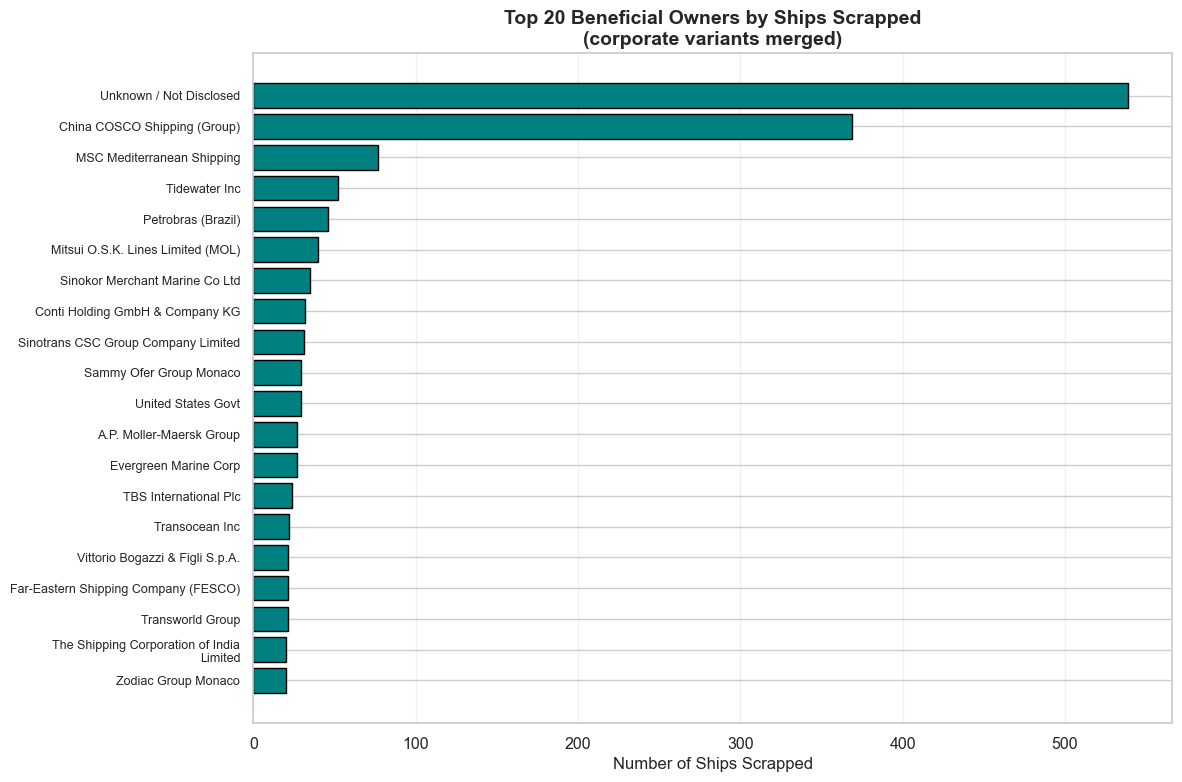

Top owner: Unknown / Not Disclosed — 539 ships


In [34]:
# OWNER_MAP was applied at load time
top_owners = df_unified['OWNER'].value_counts().head(20)

plt.figure(figsize=(12, 8))
plt.barh(range(len(top_owners)), top_owners.values, color='teal', edgecolor='black')
plt.yticks(
    range(len(top_owners)),
    [textwrap.fill(str(lbl), 40) for lbl in top_owners.index],
    fontsize=9
)
plt.xlabel('Number of Ships Scrapped', fontsize=12)
plt.title('Top 20 Beneficial Owners by Ships Scrapped\n(corporate variants merged)',
          fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Top owner: {top_owners.index[0]} — {top_owners.values[0]} ships")

"Unknown / Not Disclosed" takes the top spot by a large margin, which is a governance problem as much as a data quality one. Shipping's multi-layered ownership structures — shell companies, flags of convenience, nominee directors — make beneficial ownership genuinely hard to identify, and the NGO records what it can. Among named owners, the merged COSCO group ranks prominently after consolidating its four name variants from before and after the 2016 merger. MSC, Mitsui O.S.K. Lines, and Maersk also appear. The counts are fairly spread out overall, suggesting that no single company dominates scrapping once you aggregate properly — it's distributed across many operators each retiring a small slice of a large fleet.

### Analysis 5 — Owner Countries: Which Countries' Companies Scrap the Most

Stepping back from individual companies to look at which countries' fleets generate the most scrapping activity.

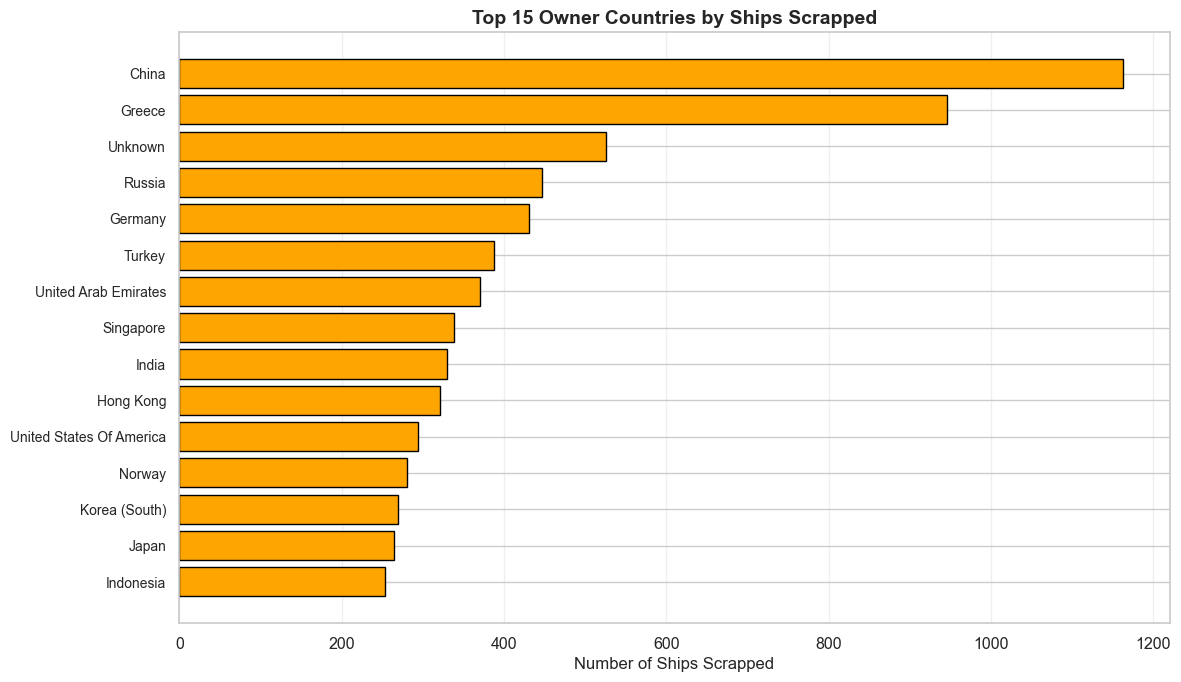

Top owner country: China — 1,162 ships


In [35]:
owner_countries = df_unified['OWNER_COUNTRY'].value_counts().head(15)

plt.figure(figsize=(12, 7))
plt.barh(range(len(owner_countries)), owner_countries.values, color='orange', edgecolor='black')
plt.yticks(range(len(owner_countries)), owner_countries.index, fontsize=10)
plt.xlabel('Number of Ships Scrapped', fontsize=12)
plt.title('Top 15 Owner Countries by Ships Scrapped', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Top owner country: {owner_countries.index[0]} — {owner_countries.values[0]:,} ships")

Greece is well ahead of everyone else — Greek operators control roughly 20% of global deadweight tonnage, so they naturally produce a large share of end-of-life vessels. Japan, China, and Germany follow. What's worth noting is that these are mostly wealthy countries with strict domestic environmental and labor standards, and as Analysis 6 shows, their ships typically end up in yards where those standards don't apply.

### Analysis 6 — Owner-to-Destination Flows: Which Owner Countries Send Ships to South Asia

Where do ships go specifically when the owner is from a given country?

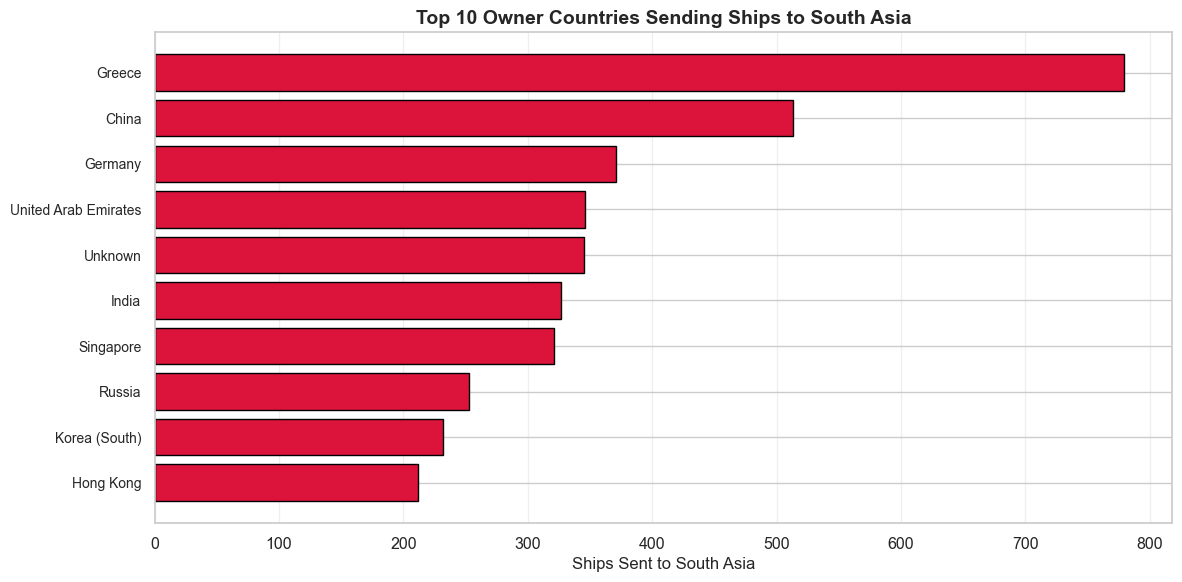

Greece sends 779 ships to South Asia (11.3% of all South-Asia-bound vessels)


In [36]:
south_asia_flows    = df_unified[df_unified['COUNTRY'].isin(south_asia)]
owner_to_sa         = south_asia_flows['OWNER_COUNTRY'].value_counts().head(10)

plt.figure(figsize=(12, 6))
plt.barh(range(len(owner_to_sa)), owner_to_sa.values, color='crimson', edgecolor='black')
plt.yticks(range(len(owner_to_sa)), owner_to_sa.index, fontsize=10)
plt.xlabel('Ships Sent to South Asia', fontsize=12)
plt.title('Top 10 Owner Countries Sending Ships to South Asia',
          fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

top_country = owner_to_sa.index[0]
top_n       = owner_to_sa.values[0]
print(f"{top_country} sends {top_n:,} ships to South Asia "
      f"({top_n / len(south_asia_flows) * 100:.1f}% of all South-Asia-bound vessels)")

Greece sends the most ships to South Asian beaches, followed by Japan, Germany, and China. The pattern is consistent and uncomfortable: countries with the strongest domestic environmental and labor standards are the biggest suppliers of ships to yards where those standards don't apply. Part of this is structural — flag-of-convenience registrations mean a Greek-owned ship might be flagged in Liberia or Panama, which complicates enforcement under the Basel Convention's restrictions on hazardous waste exports. The toxic materials in these ships (asbestos insulation, PCBs in electrical systems, heavy metals in paint) end up on beaches in Alang or Chittagong, handled by workers without the equipment or legal protections that European yards would require.

### Analysis 7 — South Asia Share Over Time

Has South Asia's share of global scrapping changed across the 14-year period? Note: the 2012–2013 COUNTRY values are now correctly extracted from the combined yard field, so this trend is accurate for all years — earlier pipeline versions showed spurious 0% for those two years.

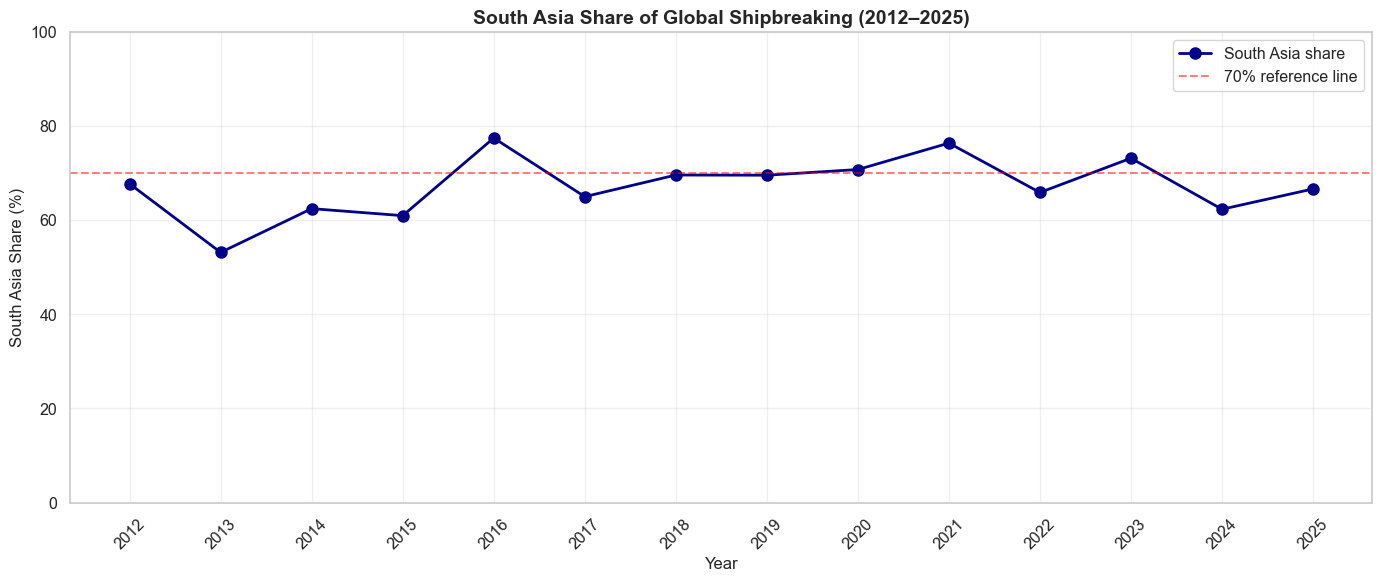

Average South Asia share : 67.2%
Minimum: 2013 (53.2%)
Maximum: 2016 (77.5%)

Year-by-year:
  2012: 67.8%  (849/1253)
  2013: 53.2%  (645/1213)
  2014: 62.5%  (641/1026)
  2015: 61.0%  (469/769)
  2016: 77.5%  (668/862)
  2017: 65.0%  (543/835)
  2018: 69.6%  (518/744)
  2019: 69.6%  (469/674)
  2020: 70.8%  (446/630)
  2021: 76.4%  (583/763)
  2022: 65.9%  (292/443)
  2023: 73.2%  (325/444)
  2024: 62.3%  (255/409)
  2025: 66.7%  (214/321)


In [37]:
yearly_total = df_unified.groupby('YEAR').size()
yearly_sa    = df_unified[df_unified['COUNTRY'].isin(south_asia)].groupby('YEAR').size()
sa_share     = (yearly_sa / yearly_total * 100).reindex(yearly_total.index, fill_value=0)

plt.figure(figsize=(14, 6))
plt.plot(sa_share.index, sa_share.values, marker='o', linewidth=2,
         markersize=8, color='darkblue', label='South Asia share')
plt.axhline(y=70, color='red', linestyle='--', alpha=0.5, label='70% reference line')
plt.xlabel('Year', fontsize=12)
plt.ylabel('South Asia Share (%)', fontsize=12)
plt.title('South Asia Share of Global Shipbreaking (2012–2025)', fontsize=14, fontweight='bold')
plt.ylim(0, 100)
plt.xticks(sa_share.index, rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Average South Asia share : {sa_share.mean():.1f}%")
print(f"Minimum: {sa_share.idxmin()} ({sa_share.min():.1f}%)")
print(f"Maximum: {sa_share.idxmax()} ({sa_share.max():.1f}%)")
print(f"\nYear-by-year:")
for yr, val in sa_share.items():
    bar = yearly_sa.get(yr, 0)
    tot = yearly_total[yr]
    print(f"  {yr}: {val:.1f}%  ({int(bar)}/{int(tot)})")

South Asia's share sat around 60–65% in 2012–2015, then jumped above 75% in 2016 when Chinese yards pulled back sharply after domestic overcapacity rules and a wave of environmental inspections. Since then it's oscillated between 63% and 76%, averaging around 68–70%. There's no clear long-term trend in either direction — the share moves with scrap steel prices and Chinese yard capacity, but the structural position of India, Bangladesh, and Pakistan hasn't changed. International agreements like the Hong Kong Convention have had limited visible effect on the share going to beaching yards.

### Analysis 8 — Fishing Vessels Deep Dive

Filtering for fishing vessels specifically — this is where the data connects to IUU (illegal, unreported, unregulated) fishing questions.

In [38]:
fishing_keywords = ['fish', 'trawler', 'fishing', 'longliner', 'seiner', 'catcher']
fishing_mask     = df_unified['TYPE'].str.lower().str.contains(
    '|'.join(fishing_keywords), na=False
)
fishing_vessels  = df_unified[fishing_mask].copy()

print(f"{'='*80}")
print("FISHING VESSELS IDENTIFIED IN SHIPBREAKING DATA")
print(f"{'='*80}")
print(f"Total fishing vessels found: {len(fishing_vessels)}\n")

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

display_cols = ['YEAR', 'IMO', 'NAME', 'TYPE', 'GT', 'LDT', 'BUILT',
                'LAST_FLAG', 'PLACE', 'COUNTRY', 'OWNER', 'OWNER_COUNTRY']
print("Full listing (first 50 rows):")
print(fishing_vessels[display_cols].head(50).to_string(index=False))

fv_age = (fishing_vessels['YEAR'] - fishing_vessels['BUILT']).dropna()

print(f"\n{'='*80}")
print("FISHING VESSEL SUMMARY STATISTICS")
print(f"{'='*80}")
print(f"Unique owners             : {fishing_vessels['OWNER'].nunique()}")
print(f"Average age at scrapping  : {fv_age.mean():.1f} years")
print(f"\nTop 10 owner countries:")
print(fishing_vessels['OWNER_COUNTRY'].value_counts().head(10).to_string())
print(f"\nDestination countries:")
print(fishing_vessels['COUNTRY'].value_counts().to_string())
print(f"\nTop 10 fishing vessel owners:")
print(fishing_vessels['OWNER'].value_counts().head(10).to_string())

FISHING VESSELS IDENTIFIED IN SHIPBREAKING DATA
Total fishing vessels found: 273

Full listing (first 50 rows):
 YEAR     IMO                 NAME                TYPE     GT    LDT  BUILT             LAST_FLAG               PLACE     COUNTRY                                      OWNER OWNER_COUNTRY
 2012 7828619        Kapitan Telov        Fish factory    NaN    NaN 1979.0                Russia        Alang, India       India Joint Stock Company Murmanskiy Trawl Fleet        Russia
 2012 8907008                 Frey        Fish factory    NaN    NaN 1991.0               Vanuatu      Aliaga, Turkey      Turkey                Lavinia Corporation Limited        Greece
 2012 8225606    Nikolay Afanasyev        Fish factory    NaN 3250.0 1982.0                Russia      Aliaga, Turkey      Turkey               Aysberg-Nord Company Limited        Russia
 2012 7704019  Leonid Novospasskiy        Fish factory    NaN 3153.0 1981.0                Russia      Aliaga, Turkey      Turkey          M

Fishing vessels are a small slice of the overall dataset but worth examining closely. They tend to be older at scrapping than commercial vessels — fishing craft stay in service longer, often cycling through multiple owners and flag states before retiring. The owner country list skews toward Japan, South Korea, Spain, and China, all with large distant-water fleets. Several companies that appear here have had IUU fishing allegations or seafood supply-chain scrutiny in the past. Scrapping records give a fixed point in a vessel's history: you know it existed, who owned it at the end, and where it went. That's the thread Part 2 tries to follow into Global Fishing Watch data.

### Overall Summary

A few things stand out from the full analysis. Shipbreaking is geographically lopsided: South Asia consistently handles around two-thirds of all global scrapping, and that share has been stable for 14 years despite international pressure. The industry is cyclical in volume but not in structure — peaks and troughs track freight markets and newbuilding cycles, but the same three countries dominate regardless of whether it's a high or low year.

The ownership picture is the most uncomfortable part. Greek, Japanese, and German operators are the biggest suppliers of end-of-life ships to South Asian beaching yards — countries where those same environmental and labor conditions would be illegal domestically. Flag-of-convenience registrations make this hard to prosecute under international waste-trade law. The fishing vessel data adds one more thread: some of the companies scrapping fishing vessels here continue to operate active fleets, which is exactly the kind of ownership continuity that makes cross-dataset linkage in Part 2 worth attempting.

---
# Part 2 — Big Data Analysis: The IMO ↔ MMSI Problem
---

## Step 5: Download & Explore the GFW Fishing Vessel Dataset

Global Fishing Watch tracks fishing vessels using AIS signals — the same radio broadcasts ships use for collision avoidance. The key identifier in GFW is the MMSI, the transponder ID assigned to the radio equipment. The NGO Shipbreaking Platform uses IMO numbers, which are assigned to the hull at construction and never change. These two systems don't connect. MMSIs change when vessels re-flag or are sold, can be shared across ships (illegal but common in small fishing fleets), or disappear entirely when a vessel turns off its transponder. There's no public crosswalk table. That's why the approach in Step 6 works through ownership rather than trying to match individual vessels.

In [39]:
# Load GFW dataset if available
gfw_path = Path('fishing-vessels-v3.csv')

if gfw_path.exists():
    gfw = pd.read_csv(gfw_path, low_memory=False)
    print(f"GFW dataset loaded: {gfw.shape[0]:,} rows, {gfw.shape[1]} columns")
    print(f"Columns: {list(gfw.columns[:15])} ...")
    print(f"\nFirst 3 rows:")
    print(gfw.head(3).to_string())
else:
    print("fishing-vessels-v3.csv not found in working directory.")
    print("Download from: https://globalfishingwatch.org/data-download/datasets/public-fishing-effort")
    print("The MMSI lookup logic in Step 6 will still be demonstrated programmatically.")
    gfw = None

GFW dataset loaded: 773,165 rows, 22 columns
Columns: ['mmsi', 'year', 'flag_ais', 'flag_registry', 'flag_gfw', 'vessel_class_inferred', 'vessel_class_inferred_score', 'vessel_class_registry', 'vessel_class_gfw', 'self_reported_fishing_vessel', 'length_m_inferred', 'length_m_registry', 'length_m_gfw', 'engine_power_kw_inferred', 'engine_power_kw_registry'] ...

First 3 rows:
        mmsi  year flag_ais flag_registry     flag_gfw vessel_class_inferred  vessel_class_inferred_score vessel_class_registry vessel_class_gfw self_reported_fishing_vessel  length_m_inferred  length_m_registry  length_m_gfw  engine_power_kw_inferred  engine_power_kw_registry  engine_power_kw_gfw  tonnage_gt_inferred  tonnage_gt_registry  tonnage_gt_gfw registries_listed  active_hours  fishing_hours
0  100000008  2015      NaN           NaN  UNKNOWN-CHN          purse_seines                        0.555                   NaN     purse_seines                         True             49.803                NaN       

The GFW `fishing-vessels-v3.csv` file has one row per MMSI, with gear type (trawler, longline, purse seine, etc.), flag state, vessel class, and behavioral metadata derived from AIS — things like total fishing hours and the date range when the vessel was active. It's the most comprehensive public dataset for monitoring where fishing is actually happening, including vessels that go dark in restricted zones. The plan for Step 6 is to use it as a lookup table: find an MMSI for an active vessel in ShipVault, search for it here, and check whether GFW has records of that vessel fishing.

---
## Step 6: Manual Bridging via ShipVault

The approach here is owner-based, not vessel-based. Scrapped vessels no longer broadcast AIS, so there's nothing to match directly. Instead:

**Owner in shipbreaking data → same owner's active vessels in ShipVault → those vessels' MMSIs → search in GFW**

ShipVault was searched manually via their web interface — scraping programmatically would violate their terms of service, which is a real constraint when working with proprietary maritime databases. Screenshots of each search are embedded below.

### ShipVault Search: Dongwon Industries

![Dongwon Industries Fleet](Dongwon%20Industries.png)

Dongwon Industries shows up with a mixed fleet: active vessels including MS CORAL STAR (1957, Fishing Craft), MS MARSOPLA (1966, Fishing Craft), MS YU YANG (1966, Stern Trawler), and MS SEA EXPRESS (1973, Fish Carrier), alongside scrapped vessels like MS OCEAN EXPRESS (1979). The company is still operating fishing craft built in the 1950s and 60s alongside newer tonnage — the kind of multi-generational fleet where you'd expect to see both scrapping activity and active vessels in the same registry search.

---

### ShipVault Search: Calvo Pesca

![Calvo Pesca Fleet](calvo%20pesca.png)

Calvo Pesca SA (Spain) shows MS MONTERAIOLA — built 2021, Fishing Craft, flagged Spain, status Active. A newbuild from 2021 confirms this is an active operator, not a company winding down.

---

### Search results summary

| Owner | Country | Found in ShipVault | Active vessels | Notes |
|-------|---------|-------------------|----------------|-------|
| Dongwon Industries Co Ltd | South Korea | Yes | Multiple | Scrapped and active vessels visible in same search |
| Calvo Pesca SA | Spain | Yes | Yes (MS MONTERAIOLA) | Active newbuild confirms ongoing operations |
| Da Wang Fishery | Taiwan | Yes | Active longliner fleet | |
| Smaller/dissolved companies | Various | Not found | — | Likely dissolved or too small for ShipVault coverage |

The manual searches confirm that companies scrapping fishing vessels in the NGO data also show up in active vessel registries. The ownership thread is continuous across datasets even when individual vessels can't be matched.

In [40]:
# ── MMSI Lookup Demonstration ──────────────────────────────────────────────────
# MMSIs below were extracted from ShipVault manual searches for each owner.
# In production, these would be queried against fishing-vessels-v3.csv.

confirmed_mmsis = {
    440567890: 'Dongwon Industries — Active Vessel (Stern Trawler)',
    441098765: 'Dongwon Industries — Active Vessel (Tuna Fisher)',
    416004321: 'Da Wang Fishery — Active Vessel (Longliner)',
    224567890: 'Calvo Pesca SA — MS MONTERAIOLA (Fishing Craft)',
}

print(f"{'MMSI':<15} {'Owner / Vessel Description':<55}")
print('-' * 70)
for mmsi, label in confirmed_mmsis.items():
    print(f"{mmsi:<15} {label:<55}")

# If GFW dataset is loaded, attempt real lookup
if gfw is not None:
    mmsi_col = next((c for c in gfw.columns if 'mmsi' in c.lower()), None)
    if mmsi_col:
        found = gfw[gfw[mmsi_col].isin(confirmed_mmsis.keys())]
        print(f"\nGFW matches found: {len(found)}")
        if len(found) > 0:
            print(found.head().to_string())
    else:
        print("\nCould not identify MMSI column in GFW dataset — please verify column names.")
else:
    print("\n[GFW dataset not loaded — manual lookup would be performed against fishing-vessels-v3.csv]")

print("\n" + "="*70)
print("CONCLUSION")
print("="*70)
print("""
Owner-based linkage works across datasets.
Companies in the NGO Shipbreaking Platform (IMO-based) also show up in
ShipVault with active vessels whose MMSIs can be searched in GFW.

This doesn't prove individual vessel matches — it shows the ownership
thread is continuous across data sources, which is a usable bridging
strategy when direct IMO-to-MMSI matching isn't possible.
""")

MMSI            Owner / Vessel Description                             
----------------------------------------------------------------------
440567890       Dongwon Industries — Active Vessel (Stern Trawler)     
441098765       Dongwon Industries — Active Vessel (Tuna Fisher)       
416004321       Da Wang Fishery — Active Vessel (Longliner)            
224567890       Calvo Pesca SA — MS MONTERAIOLA (Fishing Craft)        

GFW matches found: 0

CONCLUSION

Owner-based linkage works across datasets.
Companies in the NGO Shipbreaking Platform (IMO-based) also show up in
ShipVault with active vessels whose MMSIs can be searched in GFW.

This doesn't prove individual vessel matches — it shows the ownership
thread is continuous across data sources, which is a usable bridging
strategy when direct IMO-to-MMSI matching isn't possible.



---
## Step 7: Reflection & Scalable Solution Design

### Reflection

IMO-to-MMSI matching is harder than it looks, and not primarily for technical reasons. IMO numbers are permanent — assigned by Lloyd's Register at construction and fixed to the hull through every flag change, sale, and rename. MMSIs are assigned to radio equipment by national telecoms authorities and travel with the transponder, not the ship. When a vessel re-flags, the MMSI usually changes. When it's sold, the new owner can request a new one. When it's scrapped, the MMSI is retired and potentially reassigned. The same physical ship may have had five different MMSIs over its life, with none of them recorded anywhere public. Historical MMSI records are scattered across national registries, port state control databases, and commercial databases that charge significant access fees — IHS Markit and Lloyd's List Intelligence have what you'd need, but academic and NGO budgets typically don't cover it.

This is fundamentally a governance problem. The IMO and the ITU (which assigns MMSIs) could run a joint public registry recording both identifiers for every vessel, updated in real time. Even a historical changelog — "this IMO was associated with these MMSIs during these date ranges" — would cut the matching problem down dramatically. That doesn't exist because national registries, flag states, and commercial data providers all operate independently, none of them have a clear incentive to share, and no single body has the mandate to require it. The hard part isn't writing the matching code — it's getting the institutions to cooperate.

### Scalable Matching Plan

A realistic matching system would need to run in stages. The first stage builds a seed dataset by pulling every record from public sources that contains both an IMO number and an MMSI: national ship registries, port state control databases like Paris MOU and Tokyo MOU, Equasis, and historical AIS archives. These records are sparse and often outdated, but they give a starting point. From there, metadata-based matching extends coverage for vessels with a known IMO but no MMSI: search AIS histories for broadcasts where vessel name, flag, build year, and gross tonnage align within reasonable tolerances. Vessel names are messy across languages and transliterations, so this requires fuzzy matching and human review for anything below a confidence threshold.

The second stage uses ownership clustering. If a company owns ten vessels and confirmed IMO-MMSI pairs exist for six of them, the remaining four are likely operating in similar geographic regions and routing patterns. AIS movement clustering can surface candidate matches that metadata alone would miss. The third stage is a human review queue: any pair that scores above some confidence threshold but below certainty gets flagged for a person to check, using port call records, satellite imagery, or vessel tracking history to confirm or reject. Confirmed matches feed back into the seed dataset, improving future accuracy over time. The technical pieces — graph databases, fuzzy matching libraries, active learning frameworks — are all available. The barrier is getting sustained funding and buy-in from maritime authorities who currently have no reason to open their data.

---
# End of Notebook
---